In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Result Experiment 1

In [2]:
# load results of Experiment 1
results_experiment_1 = pd.read_csv("../experiment_1_results.csv")
results_experiment_1

,class,image,prompt,num_detections,max_confidence
0,dog,000000049269.jpg,dog,1,0.883610
1,dog,000000049269.jpg,animal,2,0.593931
2,dog,000000049269.jpg,mammal,1,0.661667
3,dog,000000049269.jpg,living thing,2,0.462266
4,dog,000000170278.jpg,dog,1,0.958983
...,...,...,...,...,...
186,chair,000000537672.jpg,furniture,1,0.465207
187,chair,000000537672.jpg,object,1,0.478358
188,chair,000000545826.jpg,chair,1,0.416379
189,chair,000000545826.jpg,furniture,1,0.381017


In [3]:
classes = results_experiment_1["class"].unique()
classes

array(['dog', 'cat', 'bird', 'car', 'bicycle', 'chair'], dtype=object)

In [4]:
avg_conf = (
    results_experiment_1.groupby(["class", "prompt"])["max_confidence"]
      .mean()
      .reset_index()
)
avg_conf

,class,prompt,max_confidence
0,bicycle,bicycle,0.638771
1,bicycle,object,0.420869
2,bicycle,vehicle,0.000000
3,bird,animal,0.791563
4,bird,bird,0.821994
5,bird,living thing,0.525490
6,car,car,0.618564
7,car,object,0.520019
8,car,vehicle,0.343274
9,cat,animal,0.753297


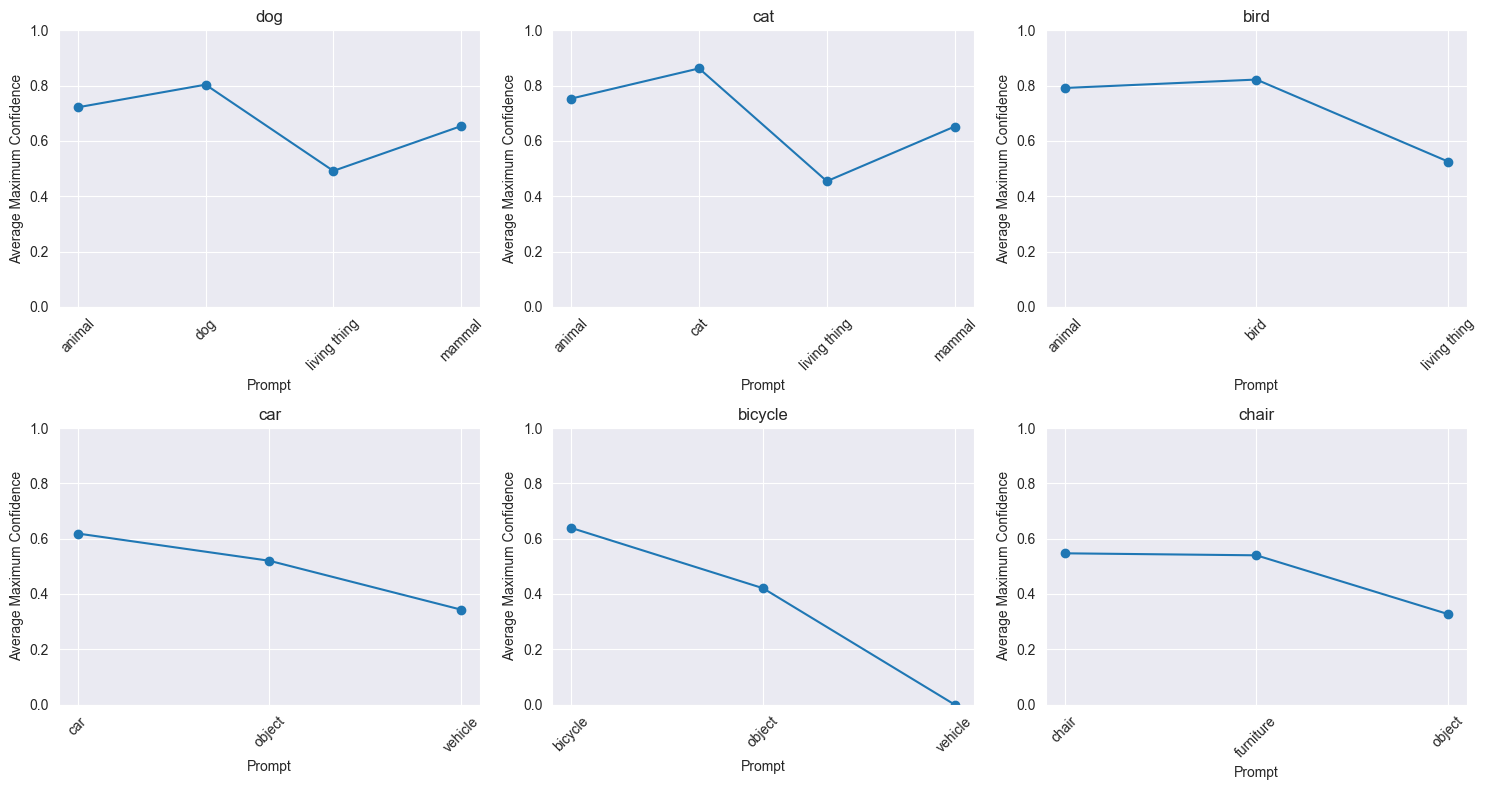

In [6]:
n_classes = len(classes)
n_cols = 3
n_rows = (n_classes + n_cols - 1) // n_cols

fix, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(15, 4 * n_rows),
    squeeze=False
)
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    class_data = avg_conf[avg_conf["class"] == cls]
    ax.plot(
        class_data["prompt"],
        class_data["max_confidence"],
        marker='o'
    )
    ax.set_title(cls)
    ax.set_xlabel("Prompt")
    ax.set_ylabel("Average Maximum Confidence")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Result Experiment 2

In [7]:
# load results of Experiment 1
results_experiment_2 = pd.read_csv("../experiment_2_results.csv")
results_experiment_2

,image,prompt,num_detections,avg_confidence
0,000000015338.jpg,object,1,0.382110
1,000000015338.jpg,thing,2,0.414161
2,000000015338.jpg,animal,1,0.531711
3,000000015338.jpg,vehicle,1,0.408760
4,000000060449.jpg,object,1,0.513562
...,...,...,...,...
115,000000577976.jpg,vehicle,2,0.670979
116,000000580418.jpg,object,0,0.000000
117,000000580418.jpg,thing,0,0.000000
118,000000580418.jpg,animal,2,0.437693


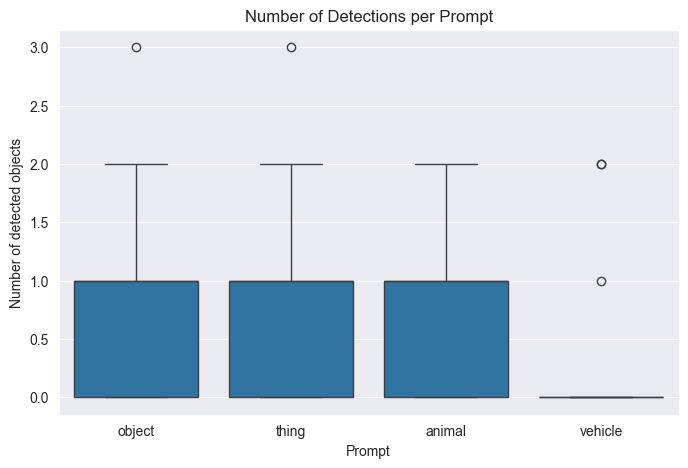

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=results_experiment_2,
    x="prompt",
    y="num_detections"
)

plt.title("Number of Detections per Prompt")
plt.xlabel("Prompt")
plt.ylabel("Number of detected objects")
plt.show()

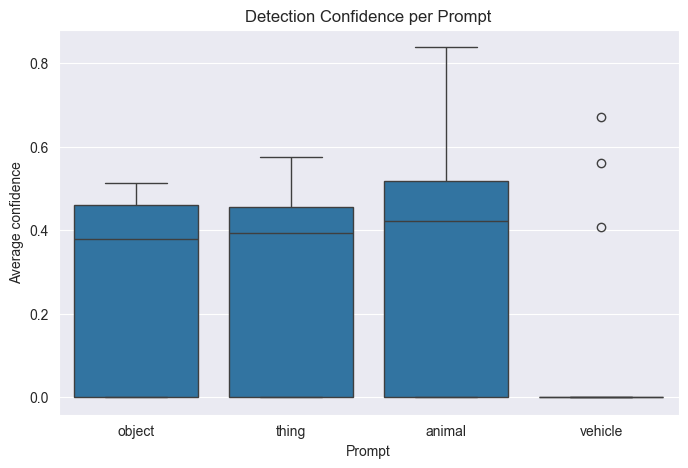

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=results_experiment_2,
    x="prompt",
    y="avg_confidence"
)

plt.title("Detection Confidence per Prompt")
plt.xlabel("Prompt")
plt.ylabel("Average confidence")

plt.show()